In [1]:
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import torchvision.transforms as transforms

class ReplicateToThreeChannels:
    def __call__(self, img):
        return img.repeat(3, 1, 1) 

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    ReplicateToThreeChannels(),  # 将单通道复制成三通道
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    # transforms.RandomRotation(10) # 调整均值和标准差为3个通道
    # transforms.Normalize(mean=[0.5], std=[0.5])  # 调整均值和标准差为3个通道
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    ReplicateToThreeChannels(),  # 将单通道复制成三通道
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


train_dataset = ChestMNIST(split="train", download=True, transform=transform,size=224, root="/home/bobsun/cambrige/MedMinist/data")
val_dataset = ChestMNIST(split="val", download=True, transform=transform_val,size=224, root="/home/bobsun/cambrige/MedMinist/data")

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/chestmnist_224.npz
Using downloaded and verified file: /home/bobsun/cambrige/MedMinist/data/chestmnist_224.npz


In [42]:
next(iter(train_loader))

[tensor([[[[ 0.3725,  0.3569,  0.3333,  ...,  0.3725,  0.3882,  0.3412],
           [ 0.3490,  0.3255,  0.3020,  ...,  0.3725,  0.3961,  0.3490],
           [ 0.3176,  0.2941,  0.2706,  ...,  0.3725,  0.3961,  0.3490],
           ...,
           [-0.9294, -0.9373, -0.9373,  ..., -0.1294, -0.0196,  0.0902],
           [-0.9294, -0.9294, -0.9373,  ..., -0.1373, -0.0196,  0.0980],
           [-0.9294, -0.9294, -0.9373,  ..., -0.1294, -0.0118,  0.0980]]],
 
 
         [[[-0.8824, -0.8667, -0.8118,  ..., -1.0000, -1.0000, -1.0000],
           [-0.8667, -0.8275, -0.7882,  ..., -1.0000, -1.0000, -1.0000],
           [-0.8510, -0.8039, -0.7725,  ..., -1.0000, -1.0000, -1.0000],
           ...,
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
           [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]]],
 
 
         [[[ 0.9608,  0.9451,  0.9137,  ...,  0.9843,  0.9922,  0.8745],
       

torch.Size([3, 224, 224])


TypeError: Invalid shape (3, 224, 224) for image data

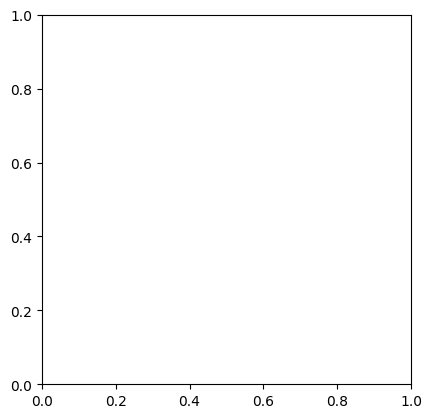

In [2]:
# 获取一个批次的数据
a = next(iter(train_loader))

import matplotlib.pyplot as plt

# 假设 a[0][0] 是单通道图像，形状为 (1, 224, 224)
image_tensor = a[0][0]
print(image_tensor.shape)
# 如果图像形状为 (1, height, width)，需要去掉第一个通道维度
image_tensor = image_tensor.squeeze()  # 形状变为 (224, 224)

# 将图像张量转换为 NumPy 数组
image_np = image_tensor.numpy()

# 使用灰度颜色映射显示单通道图像
plt.imshow(image_np, cmap="gray")
plt.show()

In [2]:
import torch
from MedMinist.resnet import ResNet18
num_epochs = 100
lr=0.0001
num_classes=14

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ResNet18(num_classes, inchannels=3)

# 加载预训练的 state_dict
pretrained_dict = torch.load('checkpoints/best_model.pth', map_location=device)
model_dict = model.state_dict()

# 用于记录匹配和不匹配的层名
matched_layers = []
unmatched_layers = []

# 筛选预训练的权重，只保留形状匹配的层
for k, v in pretrained_dict.items():
    if k in model_dict and v.size() == model_dict[k].size():
        matched_layers.append(k)  # 记录匹配的层
    else:
        unmatched_layers.append(k)  # 记录不匹配的层

# 更新模型的 state_dict，只加载匹配的层
model_dict.update({k: v for k, v in pretrained_dict.items() if k in matched_layers})
model.load_state_dict(model_dict)

# 打印报告
print("Matched Layers:")
for layer in matched_layers:
    print(f"  - {layer}")
print("\nUnmatched Layers:")
for layer in unmatched_layers:
    print(f"  - {layer}")

# 将模型移动到设备
model = model.to(device)

Matched Layers:
  - conv1.weight
  - bn1.weight
  - bn1.bias
  - bn1.running_mean
  - bn1.running_var
  - bn1.num_batches_tracked
  - layer1.0.conv1.weight
  - layer1.0.bn1.weight
  - layer1.0.bn1.bias
  - layer1.0.bn1.running_mean
  - layer1.0.bn1.running_var
  - layer1.0.bn1.num_batches_tracked
  - layer1.0.conv2.weight
  - layer1.0.bn2.weight
  - layer1.0.bn2.bias
  - layer1.0.bn2.running_mean
  - layer1.0.bn2.running_var
  - layer1.0.bn2.num_batches_tracked
  - layer1.0.deep_explain.temperature
  - layer1.0.deep_explain.W.weight
  - layer1.0.deep_explain.W.bias
  - layer1.1.conv1.weight
  - layer1.1.bn1.weight
  - layer1.1.bn1.bias
  - layer1.1.bn1.running_mean
  - layer1.1.bn1.running_var
  - layer1.1.bn1.num_batches_tracked
  - layer1.1.conv2.weight
  - layer1.1.bn2.weight
  - layer1.1.bn2.bias
  - layer1.1.bn2.running_mean
  - layer1.1.bn2.running_var
  - layer1.1.bn2.num_batches_tracked
  - layer1.1.deep_explain.temperature
  - layer1.1.deep_explain.W.weight
  - layer1.1.deep_e

In [3]:
import torch
from torch import optim, nn
from tqdm import tqdm
from torch.optim.lr_scheduler import MultiStepLR
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# 设备配置
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# 损失函数与优化器设置
criterion = nn.BCEWithLogitsLoss()  # 初始化时不使用类别权重
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
milestones = [int(0.5 * num_epochs), int(0.75 * num_epochs)]
scheduler = MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

# 训练函数
def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    total_samples = 0
    
    # 存储所有标签和预测，用于计算多标签的精确率、召回率和 F1
    all_labels = []
    all_preds = []
    
    for inputs, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        inputs, labels = inputs.to(device), labels.to(device).float()  # 转为浮点数
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # 将输出转为0或1
        outputs = torch.sigmoid(outputs)
        predicted = (outputs > 0.5).float()
        
        # 收集每个 batch 的预测结果和真实标签
        all_labels.append(labels.cpu().numpy())
        all_preds.append(predicted.cpu().numpy())
        total_samples += labels.size(0)
    
    # 汇总所有标签和预测，用于计算多标签分类的评估指标
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    # 计算每个样本的平均准确率
    sample_accuracy = (all_preds == all_labels).mean(axis=1).mean() * 100

    # 计算整体的精确率、召回率和 F1 分数
    precision = precision_score(all_labels, all_preds, average='micro')
    recall = recall_score(all_labels, all_preds, average='micro')
    f1 = f1_score(all_labels, all_preds, average='micro')

    # 输出本轮的损失和准确率信息
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Training Loss: {train_loss:.4f}, Sample Accuracy: {sample_accuracy:.2f}%")
    print(f"Training Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    return train_loss, sample_accuracy, precision, recall, f1

# 验证函数
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    total_samples = 0
    
    # 存储所有标签和预测，用于计算多标签的精确率、召回率和 F1
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            
            # 收集每个 batch 的预测结果和真实标签
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            total_samples += labels.size(0)
    
    # 汇总所有标签和预测，用于计算多标签分类的评估指标
    all_labels = np.concatenate(all_labels, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)

    # 计算每个样本的平均准确率
    sample_accuracy = (all_preds == all_labels).mean(axis=1).mean() * 100

    # 计算整体的精确率、召回率和 F1 分数
    precision = precision_score(all_labels, all_preds, average='micro')
    recall = recall_score(all_labels, all_preds, average='micro')
    f1 = f1_score(all_labels, all_preds, average='micro')

    # 输出本轮的损失和准确率信息
    val_loss = running_loss / len(val_loader)
    print(f"Validation Loss: {val_loss:.4f}, Sample Accuracy: {sample_accuracy:.2f}%")
    print(f"Validation Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

    return val_loss, sample_accuracy, precision, recall, f1

# 训练循环
best_f1 = 0.0
for epoch in range(num_epochs):
    # 训练和验证
    train_loss, train_acc, train_precision, train_recall, train_f1 = train_one_epoch(
        epoch, model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_precision, val_recall, val_f1 = validate(
        model, val_loader, criterion, device
    )
    
    # 调整学习率
    scheduler.step()

    # 保存最佳模型
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_med_chest.pth')
        print(f"Saved Best Model with F1 Score: {best_f1:.4f}")

cuda:0


Training Epoch 1: 100%|██████████| 614/614 [01:07<00:00,  9.13it/s]


Epoch 1 Training Loss: 0.1901, Sample Accuracy: 94.34%
Training Precision: 0.1236, Recall: 0.0164, F1 Score: 0.0289
Validation Loss: 0.1625, Sample Accuracy: 94.92%
Validation Precision: 0.4977, Recall: 0.0276, F1 Score: 0.0523
Saved Best Model with F1 Score: 0.0523


Training Epoch 2: 100%|██████████| 614/614 [01:04<00:00,  9.57it/s]


Epoch 2 Training Loss: 0.1602, Sample Accuracy: 94.90%
Training Precision: 0.5737, Recall: 0.0345, F1 Score: 0.0651
Validation Loss: 0.1571, Sample Accuracy: 94.93%
Validation Precision: 0.5060, Recall: 0.0473, F1 Score: 0.0864
Saved Best Model with F1 Score: 0.0864


...

Training Epoch 31: 100%|██████████| 614/614 [01:04<00:00,  9.46it/s]


Epoch 31 Training Loss: 0.0961, Sample Accuracy: 96.35%
Training Precision: 0.7551, Recall: 0.4287, F1 Score: 0.5469
Validation Loss: 0.1938, Sample Accuracy: 94.32%
Validation Precision: 0.3772, Recall: 0.1806, F1 Score: 0.2443


Training Epoch 32: 100%|██████████| 614/614 [01:03<00:00,  9.65it/s]


Epoch 32 Training Loss: 0.0940, Sample Accuracy: 96.42%
Training Precision: 0.7576, Recall: 0.4455, F1 Score: 0.5611


KeyboardInterrupt: 